# Exercises, Chapter 13, "Logistic Regression"

In [20]:
import os
import sys

import arviz
import bambi
import numpy
import pandas

from matplotlib import pyplot
from scipy import special
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

## 13.2, Sketching the logistic curve

> Sketch the following logistic regression curves with pen on paper:
>
> (a) $\text{Pr}(y = 1) = \text{logit}^{-1}(x)$
> 
> (b) $\text{Pr}(y = 1) = \text{logit}^{-1}(2 + x)$
> 
> (c) $\text{Pr}(y = 1) = \text{logit}^{-1}(2x)$
> 
> (d) $\text{Pr}(y = 1) = \text{logit}^{-1}(2 + 2x)$
> 
> (e) $\text{Pr}(y = 1) = \text{logit}^{-1}(-2x)$

In [6]:
xmax = 3
xs = numpy.arange(-1 * xmax, xmax + 0.1, 0.1)

y_a = special.expit(xs)
y_b = special.expit(xs + 2)
y_c = special.expit(2 * xs)
y_d = special.expit(2 * xs + 2)
y_e = special.expit(-2 * xs)

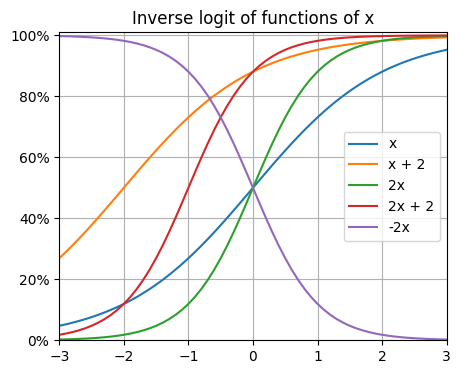

In [7]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, y_a, label='x')
ax.plot(xs, y_b, label='x + 2')
ax.plot(xs, y_c, label='2x')
ax.plot(xs, y_d, label='2x + 2')
ax.plot(xs, y_e, label='-2x')
ax.set_ylim(0, 1.01)
ax.set_yticks(
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    [f'{int(100 * yi)}%' for yi in [0, 0.2, 0.4, 0.6, 0.8, 1]],
)
ax.set_xlim(-1 * xmax, xmax)
ax.set_title('Inverse logit of functions of x')
ax.legend()
ax.grid()
ax.set_axisbelow(True)

## 13.3, Understanding logistic regression coefficients

> In Chapter 7 we fit a model predicting incumbent party’s two-party vote
> percentage given economic growth: vote = 46.2 + 3.1 * growth + error, where
> growth ranges from -0.5 to 4.5 in the data, and errors are approximately
> normally distributed with mean 0 and standard deviation 3.8. Suppose instead
> we were to fit a logistic regression,
> $\text{Pr}(\text{vote} > 50) = \text{logit}^{-1}(a + b \times \text{growth})$.
> Approximately what are the estimates of $(a, b)$?
>
> Figure this out in four steps:
>
> (i) use the fitted linear regression model to estimate Pr(vote > 50) for
>     different values of growth;
>
> (ii) second, plot these probabilities and draw a logistic curve through them;
>
> (iii) use the divide-by-4 rule to estimate the slope of the logistic
>    regression model;
>
> (iv) use the point where the probability goes through 0.5 to deduce the
>     intercept.
>
> Do all this using the above information, without downloading the data and
> fitting the model.

In [21]:
growths = numpy.arange(-0.5, 4.5 + 0.02, 0.02)
vote_shares = [46.2 + 3.1 * gi for gi in growths]
win_probs = [stats.norm.sf(50, loc=vsi, scale=3.8)
             for vsi in vote_shares]

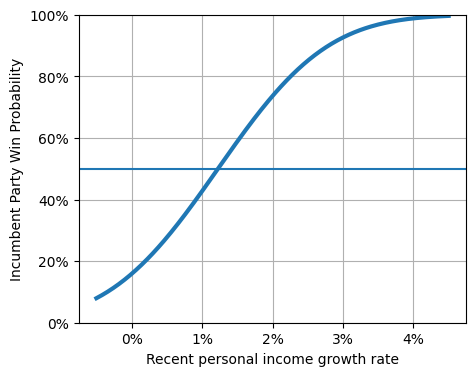

In [28]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(growths, win_probs, linewidth=3)
ax.grid()
ax.set_xticks(
    range(5),
    [str(i) + '%' for i in range(5)],
)
ax.set_xlabel('Recent personal income growth rate')
ax.set_ylim(0, 1)
yt = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(
    yt,
    [str(int(100 * yti)) + '%' for yti in yt],
)
ax.set_ylabel('Incumbent Party Win Probability')
ax.axhline(0.5)
ax.set_axisbelow(True)

In [30]:
special.expit(-1.82)  # Predicted win prob. when growth is zero

np.float64(0.13943387296165005)

## 13.4, Logistic regression with two predictors

> The following logistic regression has been fit:

```
            Median MAD_SD
(Intercept) -1.9    0.6
x            0.7    0.8
z            0.7    0.5
```

> Here, $x$ is a continuous predictor ranging from 0 to 10, and $z$ is a binary
> predictor taking on the values 0 and 1. Display the fitted model as two curves
> on a graph of $\text{Pr}(y = 1)$ vs. $x$.

In [8]:
xs = numpy.arange(0, 10.01, 0.05)
p0 = special.expit(-1.9 + 0.7 * xs)
p1 = special.expit(-1.2 + 0.7 * xs)

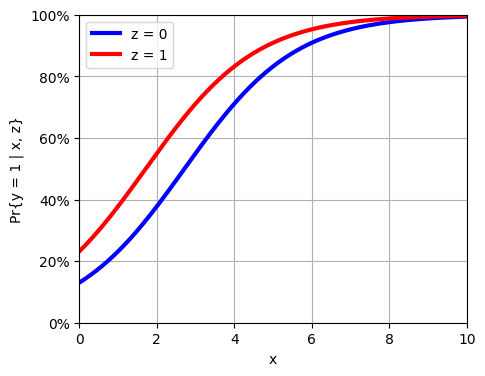

In [9]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.plot(xs, p0, 'b-', label='z = 0', linewidth=3)
ax.plot(xs, p1, 'r-', label='z = 1', linewidth=3)
ax.set_xlabel('x')
ax.set_ylabel('Pr{y = 1 | x, z}')
ax.set_ylim(bottom=0)
ax.set_xlim(0, 10)
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(0, 1)
ax.set_yticks(
    numpy.arange(0, 1.1, 0.2),
    [f'{int(100 * yi)}%' for yi in numpy.arange(0, 1.1, 0.2)],
)
ax.legend()

## 13.7, Graphing a fitted logistic regression

> We downloaded data with weight (in pounds) and age (in years) from a random
> sample of American adults. We then defined a new variable:

`heavy <- weight > 200`

> and fit a logistic regression, predicting heavy from height (in inches):

```
stan_glm(formula = heavy ~ height, family=binomial(link="logit"), data=health)

              Median MAD_SD
(Intercept)  -21.51   1.60
height         0.28   0.02
```

> (a) Graph the logistic regression curve (the probability that someone is
>     heavy) over the approximate range of the data. Be clear where the line
>     goes through the 50% probability point.
>
> (b) Fill in the blank: near the 50% point, comparing two people who differ by
>     one inch in height, you’ll expect a difference of __ in the probability of
>     being heavy.

In [10]:
# Range of heights: 5'0" to 6'6", by quarter inches
heights = numpy.arange(5 * 12, 6 * 12 + 7, 0.25)
heavies = special.expit(-21.51 + 0.28 * heights)

In [11]:
# We cross the 50% line when a + bx = 0
height50 = 21.51 / 0.28
print(f'{height50:0.1f} inches')

76.8 inches


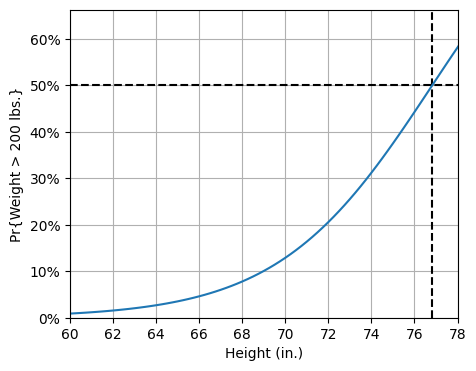

In [12]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.axvline(height50, color='k', linestyle='--')
ax.axhline(0.5, color='k', linestyle='--')
ax.plot(heights, heavies)
ax.set_xlabel('Height (in.)')
ax.set_ylabel('Pr{Weight > 200 lbs.}')
ax.set_ylim(bottom=0)
ax.set_xlim(60, 78)
ax.set_yticks(
    [0.1 * yi for yi in range(7)],
    [f'{10 * yi}%' for yi in range(7)],
)
ax.grid()
ax.set_axisbelow(True)

## 13.9, The algebra of logistic regression with one predictor

> You are interested in how well the combined earnings of the parents in a
> child’s family predicts high school graduation. You are told that the
> probability a child graduates from high school is 27% for children whose
> parents earn no income and is 88% for children whose parents earn 60,000
> dollars.  Determine the logistic regression model that is consistent with this
> information. For simplicity, you may want to assume that income is measured in
> units of 10,000.

In [13]:
a = special.logit(0.27)
b = (special.logit(0.88) - special.logit(0.27)) / 6
print(f'(a, b) = ({a:0.2f}, {b:0.2f})')

(a, b) = (-0.99, 0.50)


## 13.10, Expressing a comparison of proportions as a logistic regression

> A randomized experiment is performed within a survey, and 1000 people are
> contacted. Half the people contacted are promised a $5 incentive to
> participate, and half are not promised an incentive. The result is a 50%
> response rate among the treated group and 40% response rate among the control
> group.
> 
> (a) Set up these results as data in R. From these data, fit a logistic
>     regression of response on the treatment indicator.
> 
> (b) Compare to the results from Exercise 4.1.

In [14]:
prop_df = pandas.DataFrame(data={
    'incentivized': ([0,] * 500) + ([1,] * 500),
    'responded': ([1,] * 200) + ([0,] * 300) + ([1,] * 250) + ([0,] * 250)
})

In [15]:
prop_model = bambi.Model("responded['1'] ~ incentivized", prop_df, family="bernoulli")
prop_fit = prop_model.fit()
arviz.summary(prop_fit)

Modeling the probability that responded==1
Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, incentivized]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.404,0.093,-0.579,-0.232,0.001,0.001,4004.0,2972.0,1.0
incentivized,0.403,0.130,0.158,0.643,0.002,0.002,3838.0,3061.0,1.0


In [17]:
print(bg_ros.bambi_markdown(prop_fit, ['incentivized',], False))

Coef.     | Mean   | s.e.
--------- | ------ | ------
sigma     | nan | nan
Intercept | -0.40 | 0.09
incentivized | 0.40 | 0.13

